# Metaheuristic Optimization

**Where you leave convexity entirely — mixed-integer or non-convex.** These break the cone framework and force either mixed-integer conic solvers (MISOCP, branch-and-bound) or metaheuristics like the PSO:

- **Cardinality constraint** — "hold at most $k$ names," $\|w\|_0 \leq k$. The $\ell_0$ "norm" is non-convex (you saw this in the convex-optimization session). Needs binary variables → MISOCP, or a metaheuristic.
- **Minimum position size** — "each held position is either 0 or at least 2%" (semi-continuous variables). Discontinuous feasible set, non-convex, binary variables.
- **Integer lot sizes** — round lots, MIP.
- **Fixed transaction costs** — a flat fee per name *traded* (not proportional) introduces a binary "did I trade this" variable → non-convex.
- **Non-convex objectives** — maximizing certain risk-adjusted measures (e.g., some drawdown or Sortino-style objectives, or a hit-rate-weighted conviction score) that aren't concave.
- **Discrete conviction tiers** — if analyst views came in as discrete buckets that interact nonlinearly with sizing.

A metaheuristic is a general-purpose, derivative-free search strategy that makes almost no assumptions about the objective — no convexity, no smoothness, no gradients, sometimes not even continuity. You only need to evaluate the objective at a point. That generality is the whole point: metaheuristics are what you reach for when the problem is non-convex, discrete, black-box, or otherwise outside what exact solvers can handle. The price is always the same — approximate solutions, no optimality guarantee, stochastic (non-reproducible without a fixed seed), and many function evaluations.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

In [2]:
mu = np.array(
    [0.0720, 0.1552, 0.1754, 0.0898, 0.4290, 0.3929, 0.3217, 0.1838]
)
sigma = np.array([
    [0.0946, 0.0374, 0.0349, 0.0348, 0.0542, 0.0368, 0.0321, 0.0327],
    [0.0374, 0.0775, 0.0387, 0.0367, 0.0382, 0.0363, 0.0356, 0.0342],
    [0.0349, 0.0387, 0.0624, 0.0336, 0.0395, 0.0369, 0.0338, 0.0243],
    [0.0348, 0.0367, 0.0336, 0.0682, 0.0402, 0.0335, 0.0436, 0.0371],
    [0.0542, 0.0382, 0.0395, 0.0402, 0.1724, 0.0789, 0.0700, 0.0501],
    [0.0368, 0.0363, 0.0369, 0.0335, 0.0789, 0.0909, 0.0536, 0.0449],
    [0.0321, 0.0356, 0.0338, 0.0436, 0.0700, 0.0536, 0.0965, 0.0442],
    [0.0327, 0.0342, 0.0243, 0.0371, 0.0501, 0.0449, 0.0442, 0.0816]
])

## Particle Swarm Optimization

Particle swarm optimization is a population-based, derivative-free global optimizer. You scatter many candidate solutions ("particles") across the search space, each with a velocity; they move around, pulled toward both their own best-found position and the swarm's best-found position. Over iterations the swarm clusters toward good regions. It's a metaheuristic — no gradients, no convexity assumptions, no structure exploited at all. The ultimate black box. PSO buys generality at the cost of everything else.

You're minimizing some objective $f(x)$ where $x \in \mathbb{R}^n$. You initialize a population of $N$ particles, each one a candidate solution. Particle $i$ has two things at every step:

- a **position $x_i \in \mathbb{R}^n$** — its current candidate solution
- a **velocity** $v_i \in \mathbb{R}^n$ — the direction and speed it's moving

And the swarm tracks two "memories":

- $p_i$ — particle $i$'s **personal best** position found so far (lowest $f$ it has personally visited)
- $g$ — the **global best** position found by *any* particle so far

**The update equations.** At each iteration, every particle updates its velocity, then its position. The velocity update is the heart of it:

$$
v_i \leftarrow \underbrace{w\,v_i}_{\text{inertia}} + \underbrace{c_1 r_1 \odot (p_i - x_i)}_{\text{cognitive}} + \underbrace{c_2 r_2 \odot (g - x_i)}_{\text{social}}
$$

then the position update:

$$
x_i \leftarrow x_i + v_i
$$

Three terms in the velocity, and this is the whole algorithm:

1. **Inertia** $w\,v_i$ — keep moving in the current direction, scaled by inertia weight $w$. This is momentum; it's what makes the particle *explore* rather than immediately snapping to the best. Often $w$ is decayed over iterations (high early for exploration, low late for exploitation — the exploration/exploitation axis, made concrete).
2. **Cognitive term** $c_1 r_1 \odot (p_i - x_i)$ — pull back toward *this particle's own* best-found position. "Return toward the best I personally have seen." $c_1$ is the cognitive coefficient.
3. **Social term** $c_2 r_2 \odot (g - x_i)$ — pull toward the *swarm's* best-found position. "Move toward the best anyone has seen." $c_2$ is the social coefficient.

The $r_1, r_2$ are vectors of uniform random numbers in $[0,1]$, drawn fresh each step, and $\odot$ is elementwise multiplication. The randomness is what makes it stochastic — it perturbs the pulls so particles don't all collapse along the same line, preserving diversity in the swarm.

**The loop, in full:**

1. Initialize $N$ particles at random positions, random (or zero) velocities.
2. Evaluate $f(x_i)$ for each; set each $p_i = x_i$ and $g$ = best among them.
3. For each iteration until a stopping criterion:
    - For each particle: update velocity (the three-term equation), update position.
    - Evaluate $f$ at the new position.
    - If it beat the particle's personal best, update $p_i$.
    - If it beat the global best, update $g$.
4. Return $g$.

In [5]:
def repair_weights(w, min_pos):
    """
    Project w onto: each position is 0 or >= min_pos, weights sum to 1.

    Iteratively zeros out sub-threshold positions and renormalizes.
    The loop terminates in at most n steps (one asset removed per pass).
    """
    w = np.clip(w, 0, None)
    for _ in range(len(w)):
        total = w.sum()
        if total <= 0:
            break
        w = w / total
        below = (w > 0) & (w < min_pos)
        if not below.any():
            break
        w[below] = 0.0
    return w


def pso_max_return(mu, sigma, sigma_max, min_pos=0.10,
                   n_particles=300, n_iter=600,
                   c1=1.5, c2=1.5, seed=42): # Clerc & Kennedy (2002)
    """
    Maximize expected return via Particle Swarm Optimization.

        max  μᵀw
        s.t. √(wᵀΣw) ≤ σ_max
             Σᵢ wᵢ = 1
             wᵢ = 0  or  wᵢ ≥ min_pos    (semi-continuous)

    The semi-continuous constraint makes the feasible set disconnected,
    ruling out convex solvers. PSO explores it via a repair operator.

    Returns
    -------
    w       : optimal weights, shape (n,)
    history : global-best fitness at each iteration
    """
    rng = np.random.default_rng(seed)
    n = len(mu)

    # --- initialize ---
    X = rng.dirichlet(np.ones(n), size=n_particles)
    X = np.array([repair_weights(x, min_pos) for x in X])
    V = rng.uniform(-0.1, 0.1, size=(n_particles, n))

    def fitness(w):
        vol = np.sqrt(w @ sigma @ w)
        return float(mu @ w) - 1e4 * max(0.0, vol - sigma_max) ** 2

    F = np.array([fitness(x) for x in X])
    pbest, pbest_f = X.copy(), F.copy()
    g_idx = np.argmax(pbest_f)
    gbest, gbest_f = pbest[g_idx].copy(), pbest_f[g_idx]
    history = [gbest_f]

    # --- swarm iterations ---
    for t in range(n_iter):
        inertia = 0.9 - 0.5 * t / n_iter          # linear decay 0.9 → 0.4, empirical standards from Shi & Eberhart's 1998 paper
        r1 = rng.random((n_particles, n))
        r2 = rng.random((n_particles, n))

        V = (inertia * V
             + c1 * r1 * (pbest - X)
             + c2 * r2 * (gbest - X))
        V = np.clip(V, -0.2, 0.2)                  # velocity clamping

        X = np.array([repair_weights(x + v, min_pos) for x, v in zip(X, V)])

        F = np.array([fitness(x) for x in X])
        improved = F > pbest_f
        pbest[improved] = X[improved]
        pbest_f[improved] = F[improved]

        g_idx = np.argmax(pbest_f)
        if pbest_f[g_idx] > gbest_f:
            gbest, gbest_f = pbest[g_idx].copy(), pbest_f[g_idx]
        history.append(gbest_f)

    realized_vol = np.sqrt(gbest @ sigma @ gbest)
    if realized_vol > sigma_max * 1.01:
        raise ValueError(f"PSO failed risk constraint: σ={realized_vol:.4f} > σ_max={sigma_max}")

    return gbest, history

**Reading the dynamics intuitively.** Each particle is torn between three impulses: keep going the way I'm headed (inertia), drift back toward my own best spot (cognitive), and drift toward the swarm's best spot (social). Early on, with high inertia and particles scattered, the swarm explores broadly. As particles discover good regions, the social pull concentrates them, and as inertia decays they settle into exploitation around $g$. The balance between $c_1$ (trust yourself) and $c_2$ (trust the swarm) controls whether particles wander independently or herd quickly — too much $c_2$ and they collapse prematurely onto an early (possibly non-global) best; too little and they never converge.

**The coefficients you'd tune** (the "knobs," analogous to a learning rate):

- $w$ (inertia, ~0.7 typical, often decayed) — exploration vs exploitation
- $c_1$ (cognitive, ~1.5–2) — individual memory pull
- $c_2$ (social, ~1.5–2) — swarm pull
- $N$ (swarm size, ~20–50) — more particles = better coverage, more cost
- velocity clamping — cap $|v_i|$ so particles don't fly off to infinity

                                     PSO      SOCP
Expected return                   0.3995    0.4001
Realized σ                        0.3001    0.3000
Sum of weights                    1.0000    1.0000
# positions held                       2         3
Min non-zero weight               0.1832    0.0228

Weights by asset:
   Asset         μ         PSO        SOCP
       1    0.0720      0.0000      0.0000
       2    0.1552      0.0000      0.0000
       3    0.1754      0.0000      0.0000
       4    0.0898      0.0000      0.0000
       5    0.4290      0.1832      0.2447
       6    0.3929      0.8168      0.7325
       7    0.3217      0.0000      0.0228
       8    0.1838      0.0000      0.0000


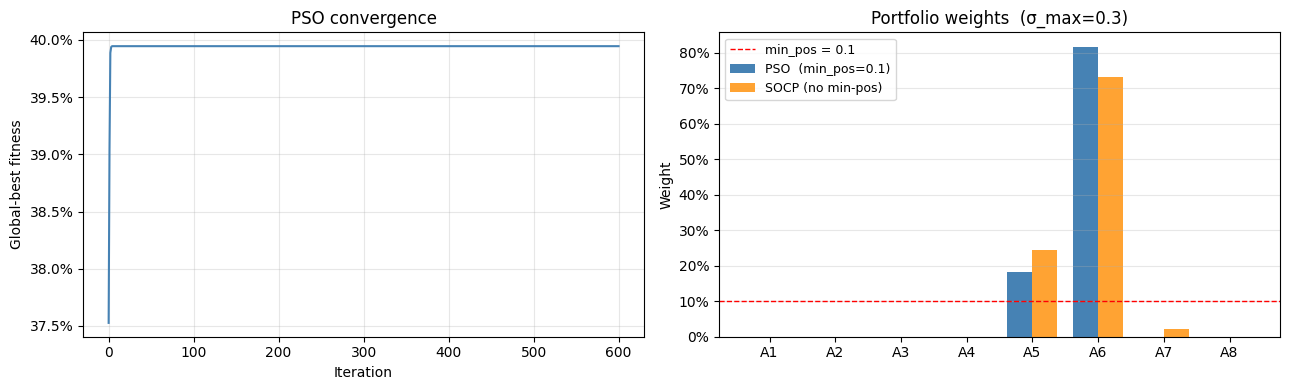

In [6]:
SIGMA_MAX = 0.30
MIN_POS   = 0.10
n = len(mu)

w_pso, history = pso_max_return(mu, sigma, sigma_max=SIGMA_MAX, min_pos=MIN_POS)

# SOCP baseline (no min-position constraint)
def socp_max_return(mu, sigma, sigma_max, long_only=True):
    L = np.linalg.cholesky(sigma)
    w = cp.Variable(n)
    constraints = [cp.norm(L.T @ w, 2) <= sigma_max, cp.sum(w) == 1]
    if long_only:
        constraints.append(w >= 0)
    prob = cp.Problem(cp.Maximize(mu @ w), constraints)
    prob.solve(solver=cp.CLARABEL)
    return w.value

w_socp = socp_max_return(mu, sigma, sigma_max=SIGMA_MAX, long_only=True)

# --- results ---
print(f"{'':30s}  {'PSO':>8}  {'SOCP':>8}")
print(f"{'Expected return':30s}  {mu @ w_pso:8.4f}  {mu @ w_socp:8.4f}")
print(f"{'Realized σ':30s}  {np.sqrt(w_pso @ sigma @ w_pso):8.4f}  {np.sqrt(w_socp @ sigma @ w_socp):8.4f}")
print(f"{'Sum of weights':30s}  {w_pso.sum():8.4f}  {w_socp.sum():8.4f}")
print(f"{'# positions held':30s}  {(w_pso > 1e-4).sum():8d}  {(w_socp > 1e-4).sum():8d}")
print(f"{'Min non-zero weight':30s}  {w_pso[w_pso > 1e-4].min():8.4f}  {w_socp[w_socp > 1e-4].min():8.4f}")
print()
print("Weights by asset:")
header = f"  {'Asset':>6}    {'μ':>6}    {'PSO':>8}    {'SOCP':>8}"
print(header)
for i, (m, wp, ws) in enumerate(zip(mu, w_pso, w_socp)):
    print(f"  {i+1:>6}    {m:6.4f}    {wp:8.4f}    {ws:8.4f}")

# --- plots ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(history, color="steelblue", lw=1.5)
ax.set_xlabel("Iteration")
ax.set_ylabel("Global-best fitness")
ax.set_title("PSO convergence")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax.grid(True, alpha=0.3)

ax = axes[1]
x = np.arange(n)
width = 0.38
bars_pso  = ax.bar(x - width/2, w_pso,  width, label=f"PSO  (min_pos={MIN_POS})", color="steelblue")
bars_socp = ax.bar(x + width/2, w_socp, width, label="SOCP (no min-pos)",          color="darkorange", alpha=0.8)
ax.axhline(MIN_POS, color="red", ls="--", lw=1, label=f"min_pos = {MIN_POS}")
ax.set_xticks(x)
ax.set_xticklabels([f"A{i+1}" for i in range(n)])
ax.set_ylabel("Weight")
ax.set_title(f"Portfolio weights  (σ_max={SIGMA_MAX})")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

- **No gradient used** — only $f$ evaluations, which is why it works on non-convex, discontinuous, or black-box objectives.
- **No convergence guarantee** — it's a heuristic. It *usually* finds a good solution but can converge prematurely to a local optimum if the social pull dominates before the swarm has explored enough.
- **Stochastic** — different random seeds give different results, the reproducibility issue that matters in production.
- **Embarrassingly parallel** — the $N$ particle evaluations at each step are independent, so it parallelizes trivially (one reason it's attractive when each $f$ evaluation is expensive but parallelizable).